In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("./data_ts/monthly-beer-production-in-austr.csv").head(200)

In [5]:
df = df.rename(columns={
    "Month" : "timestamp",
    "Monthly beer production" : "value"
})
df["timestamp"] = pd.to_datetime(df["timestamp"])

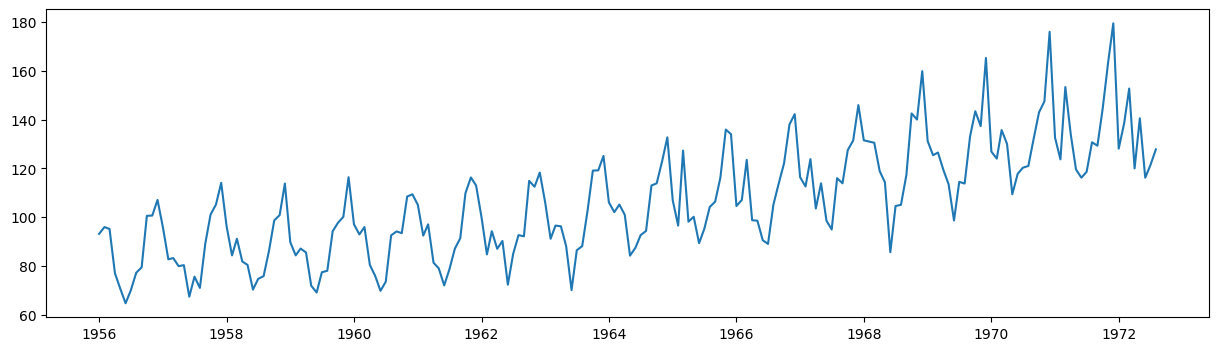

In [6]:
plt.figure(figsize=(15, 4))
plt.plot(df["timestamp"], df["value"])

In [8]:
prediction_len = 1
context_len = 5

In [9]:
ts = df["value"]

In [10]:
ts.head(10)

0     93.2
1     96.0
2     95.2
3     77.1
4     70.9
5     64.8
6     70.1
7     77.3
8     79.5
9    100.6
Name: value, dtype: float64

In [17]:
# train test spliting

In [18]:
train_ts = ts.head(160)
test_ts = ts.tail(40)

In [24]:
# remove trend
# plt.plot(ts.diff().dropna())

In [30]:
# impute
# ts.diff().ffill().bfill()

In [35]:
xTrain = []
yTrain = []

for i in range(len(train_ts)-context_len):
    x = train_ts.iloc[i:i+context_len].values.astype(float)
    y = train_ts.iloc[i+context_len:i+context_len+prediction_len].values.astype(float)
    xTrain.append(x)
    yTrain.append(y)

xTrain = np.array(xTrain)
yTrain = np.array(yTrain)

In [36]:
xTest = []
yTest = []

for i in range(len(test_ts)-context_len):
    x = test_ts.iloc[i:i+context_len].values.astype(float)
    y = test_ts.iloc[i+context_len:i+context_len+prediction_len].values.astype(float)
    xTest.append(x)
    yTest.append(y)
    
xTest = np.array(xTest)
yTest = np.array(yTest)

In [37]:
xTrain.shape

(155, 5)

In [39]:
xTest.shape

(35, 5)

## LSTM
https://colah.github.io/posts/2015-08-Understanding-LSTMs/

In [40]:
from tensorflow.keras import layers
import tensorflow as tf

2025-07-30 22:26:12.182717: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [43]:
xTrain = np.expand_dims(xTrain, -1)
xTest = np.expand_dims(xTest, -1)

In [ ]:
layers.Bidirectional()

In [57]:
input_layers = tf.keras.Input(shape=(xTrain.shape[1:]))

model = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(input_layers)
model = layers.Dropout(0.2)(model)
model = layers.LSTM(16, return_sequences=True)(model)
model = layers.Dropout(0.2)(model)
model = layers.LSTM(16, return_sequences=False)(model)
model = layers.Dropout(0.2)(model)
model = layers.Dense(1, activation='linear')(model)

model = tf.keras.Model(input_layers, model)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 5, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 5, 64)          │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 5, 16)          │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,017 (62.57 KB)

 Trainable params: 16,017 (62.57 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(optimizer="adam", loss="mse")

In [56]:
model.fit(xTrain, yTrain, validation_data=(xTest, yTest), batch_size=16, epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 10512.7197 - val_loss: 18330.5957
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10186.0166 - val_loss: 18195.0840
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10233.7559 - val_loss: 18002.3223
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9925.3818 - val_loss: 17747.4922
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10150.7363 - val_loss: 17462.9707
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9736.5381 - val_loss: 17192.3613
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9114.2285 - val_loss: 16958.3164
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9404.1699 - val_loss: 16769.1016
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9493.4355 - val_loss: 16619.9473
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9026.3896 - val_loss: 16506.8711
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8767.0176 - va

In [73]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [70]:
rf = RandomForestRegressor()
rf.fit(xData, yData)
y_pred = rf.predict(xData)

/Users/hanif/miniconda3/envs/mlseq/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [74]:
mean_squared_error(yData, y_pred)

0.9367564564102561